# 15 — Rights as a partial order

Classify each `(period, group, resource_type)` cell as granted (`net ≥ 1`) or denied (`net ≤ 0`), build the per-period partial order on groups via $S_B \subseteq S_A$, and ask whether rights expand across the four periods.

$$
\text{net}(p, g, r) = \#\text{MORE}(p, g, r) - \#\text{LESS}(p, g, r)
\qquad
g_A \succeq_p g_B \iff S_{p,g_B} \subseteq S_{p,g_A}
$$

## 1. Configuration

In [1]:
import random
from itertools import product

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np
import pandas as pd

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Paths
DATA_PATH = "../data/rules_dataset_april_2026.tsv"

# Threshold rule (binary — no indeterminate state):
#   net >= 1  -> granted
#   net <= 0  -> denied
GRANT_THRESHOLD = 1
MIN_RULES_PER_GROUP = 5  # drop groups with fewer rules in a given period

# Style — Science/Nature minimal
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "font.family": "DejaVu Sans",
})
PALETTE = {
    "granted":      "#1f77b4",
    "denied":       "#d62728",
    "no_evidence":  "#f0f0f0",
    "node":         "#2c3e50",
    "edge":         "#7f8c8d",
}

# Period order — chronological
PERIOD_ORDER = [
    "Classical (500–360 BCE)",
    "Late Classical (354–165 BCE)",
    "Hellenistic & Early Roman (165 BCE – 105 CE)",
    "High Roman Empire (135–205 CE)",
]
PERIOD_SHORT = {
    "Classical (500–360 BCE)":                       "Classical",
    "Late Classical (354–165 BCE)":                  "Late Classical",
    "Hellenistic & Early Roman (165 BCE – 105 CE)":  "Hellenistic / E. Roman",
    "High Roman Empire (135–205 CE)":                "High Roman",
}


## 2. Load data

In [2]:
df_raw = pd.read_csv(DATA_PATH, sep="\t")
print(f"Loaded {len(df_raw):,} rules across {df_raw['period'].nunique()} periods.")
df_raw.head(3)

Loaded 1,011 rules across 4 periods.


,rule_id,perseus_author,perseus_title,period,source_type,source_type_description,rule,verbatim,reasoning,directionality,...,resource_persistence,persistence_reasoning,group_immutability,immutability_reasoning,rule_contemporarity,contemporarity_reasoning,opinion_vs_fact,opinion_vs_fact_reasoning,tautology,tautology_reasoning
0,tlg0007.tlg118.perseus-eng3::0,Plutarch,Precepts of Statecraft,Hellenistic & Early Roman (165 BCE – 105 CE),contemporary_treatise,Contemporary philosophical / political treatis...,Greek exclusion from large-scale statecraft,['The exercise of statecraft on a large scale ...,The text describes a systematic restriction wh...,LESS,...,4,Exclusion from high office is a durable career...,5,Greek ethnicity is a birth-fixed biological/cu...,1,Plutarch describes the current Roman administr...,5,Verbatim states the limitation as a plain hist...,0,Ethnicity does not inherently define level of ...
1,tlg0007.tlg118.perseus-eng3::1,Plutarch,Precepts of Statecraft,Hellenistic & Early Roman (165 BCE – 105 CE),contemporary_treatise,Contemporary philosophical / political treatis...,City-state local self-government,"['The ancient Greek city-states retained, howe...","Under Roman rule, Greek citizens retained spec...",MORE,...,5,A city's status and its citizens' collective r...,4,Citizenship in a Greek city-state is a rigid l...,1,Refers to the existing status of Greek cities ...,5,Describes the retention of local rights as a r...,0,Being a citizen of a city does not inherently ...
2,tlg0007.tlg118.perseus-eng3::2,Plutarch,Precepts of Statecraft,Hellenistic & Early Roman (165 BCE – 105 CE),contemporary_treatise,Contemporary philosophical / political treatis...,Noble access to magistracies,"['Therefore, seeing that the desire has been a...","Plutarch addresses Menemachus, stating that pu...",MORE,...,4,Elite status and eligibility for office are ty...,5,'Noble birth' is a strictly immutable lineage-...,1,Plutarch addresses a living recipient about hi...,4,"Frames eligibility as a matter of birthright, ...",0,Nobility does not always formally mandate poli...


In [3]:
# Sanity check: the four periods in PERIOD_ORDER all exist
missing = set(PERIOD_ORDER) - set(df_raw["period"].unique())
assert not missing, f"Missing periods in data: {missing}"

# Directionality must be in {MORE, LESS}
assert set(df_raw["directionality"].dropna().unique()) <= {"MORE", "LESS"}

df_raw["period"].value_counts().reindex(PERIOD_ORDER)

period
Classical (500–360 BCE)                         283
Late Classical (354–165 BCE)                    397
Hellenistic & Early Roman (165 BCE – 105 CE)    155
High Roman Empire (135–205 CE)                   85
Name: count, dtype: int64

## 3. Preprocessing — explode multi-valued cells

`group_meta` and `resource_type` use `;` to encode conjunctions. Treat each atom independently: a rule granting `Citizens; Men` access to `Political Power; Material Wealth` becomes 4 rows.

In [4]:
def split_atoms(s: str) -> list[str]:
    """Split a semicolon-separated string into stripped non-empty atoms."""
    if pd.isna(s):
        return []
    return [x.strip() for x in str(s).split(";") if x.strip()]

# Drop the raw group / resource_type columns first so renaming below is unambiguous.
df = df_raw.drop(columns=["group", "resource", "resource_type"], errors="ignore").copy()
df["group_atoms"]    = df_raw["group_meta"].apply(split_atoms)
df["resource_atoms"] = df_raw["resource_type"].apply(split_atoms)

before = len(df)
df = df.explode("group_atoms").explode("resource_atoms")
df = df.rename(columns={"group_atoms": "group", "resource_atoms": "resource"})
df = df.dropna(subset=["group", "resource", "directionality", "period"])
after = len(df)

print(f"Rows before explode: {before:,}")
print(f"Rows after explode : {after:,}  (+{after - before:,})")
print(f"Atomic groups        : {df['group'].nunique()}")
print(f"Atomic resource types: {df['resource'].nunique()}")

df[["period", "group", "resource", "directionality"]].sample(5, random_state=SEED)


Rows before explode: 1,011
Rows after explode : 1,227  (+216)
Atomic groups        : 35
Atomic resource types: 8


,period,group,resource,directionality
865,Classical (500–360 BCE),Philosophers,Political Power,MORE
219,Late Classical (354–165 BCE),The wealthy,Material Wealth,LESS
883,Classical (500–360 BCE),Men,Political Power,MORE
220,Late Classical (354–165 BCE),The poor,Political Power,MORE
76,Late Classical (354–165 BCE),Minors,Political Power,LESS


In [5]:
# Integrity check — no row lost a key column during explode
assert df["group"].notna().all()
assert df["resource"].notna().all()
assert df["period"].notna().all()

# Per-period coverage
df.groupby("period").size().reindex(PERIOD_ORDER).rename("n_rows_after_explode").to_frame()

,n_rows_after_explode
period,
Classical (500–360 BCE),391
Late Classical (354–165 BCE),514
Hellenistic & Early Roman (165 BCE – 105 CE),219
High Roman Empire (135–205 CE),103


## 4. Net rights per (period, group, resource_type)

Pivot into a long table where each row is a `(period, group, resource)` cell with
`n_more`, `n_less` and `net = n_more − n_less`.

In [6]:
counts = (
    df.groupby(["period", "group", "resource", "directionality"])
      .size()
      .unstack("directionality", fill_value=0)
      .reindex(columns=["MORE", "LESS"], fill_value=0)
      .rename(columns={"MORE": "n_more", "LESS": "n_less"})
      .reset_index()
)
counts["net"]   = counts["n_more"] - counts["n_less"]
counts["total"] = counts["n_more"] + counts["n_less"]

print(f"(period, group, resource) cells with at least one rule: {len(counts):,}")
counts.sort_values("total", ascending=False).head(10)

(period, group, resource) cells with at least one rule: 332


directionality,period,group,resource,n_more,n_less,net,total
242,Late Classical (354–165 BCE),Citizens,Political Power,54,20,34,74
6,Classical (500–360 BCE),Citizens,Legal Standing,37,7,30,44
316,Late Classical (354–165 BCE),The poor,Political Power,12,22,-10,34
8,Classical (500–360 BCE),Citizens,Political Power,27,6,21,33
321,Late Classical (354–165 BCE),The wealthy,Material Wealth,6,23,-17,29
240,Late Classical (354–165 BCE),Citizens,Legal Standing,19,8,11,27
237,Late Classical (354–165 BCE),Citizens,Bodily Autonomy,16,10,6,26
76,Classical (500–360 BCE),The wealthy,Material Wealth,1,22,-21,23
2,Classical (500–360 BCE),Citizens,Bodily Autonomy,14,9,5,23
241,Late Classical (354–165 BCE),Citizens,Material Wealth,12,6,6,18


In [7]:
# Filter out groups with too few rules in a given period — noise floor
rules_per_period_group = (
    df.groupby(["period", "group"]).size().rename("n_rules").reset_index()
)
kept = rules_per_period_group[rules_per_period_group["n_rules"] >= MIN_RULES_PER_GROUP]

print(f"(period, group) pairs total : {len(rules_per_period_group):,}")
print(f"(period, group) pairs kept  : {len(kept):,}  (>= {MIN_RULES_PER_GROUP} rules)")

kept_keys = set(map(tuple, kept[["period", "group"]].values))
counts = counts[counts.set_index(["period", "group"]).index.isin(kept_keys)].reset_index(drop=True)

kept.sort_values(["period", "n_rules"], ascending=[True, False]).head(10)

(period, group) pairs total : 100
(period, group) pairs kept  : 50  (>= 5 rules)


,period,group,n_rules
1,Classical (500–360 BCE),Citizens,128
23,Classical (500–360 BCE),The wealthy,34
8,Classical (500–360 BCE),Men,32
25,Classical (500–360 BCE),Women,31
4,Classical (500–360 BCE),Foreigners,29
18,Classical (500–360 BCE),Slaves,25
5,Classical (500–360 BCE),Heirs,23
9,Classical (500–360 BCE),Minors,18
7,Classical (500–360 BCE),Magistrates,17
19,Classical (500–360 BCE),Soldiers,9


## 5. Threshold rule → rights sets

Binary classification — no indeterminate state:

| condition  | label   | code |
|------------|---------|------|
| `net >= 1` | granted | `+1` |
| `net <= 0` | denied  | `-1` |

`(group, resource)` cells with no rules at all are absent from the table.

In [8]:
def classify(n: int) -> int:
    return 1 if n >= GRANT_THRESHOLD else -1

counts["state"] = counts["net"].apply(classify)

print("State distribution:")
print(counts["state"].value_counts().rename({1: "granted", -1: "denied"}))
counts.head()

State distribution:
state
denied     120
granted    115
Name: count, dtype: int64


directionality,period,group,resource,n_more,n_less,net,total,state
0,Classical (500–360 BCE),Citizens,Bodily Autonomy,14,9,5,23,1
1,Classical (500–360 BCE),Citizens,Education,1,0,1,1,1
2,Classical (500–360 BCE),Citizens,Honor,3,2,1,5,1
3,Classical (500–360 BCE),Citizens,Household Authority,2,1,1,3,1
4,Classical (500–360 BCE),Citizens,Legal Standing,37,7,30,44,1


In [9]:
# Build, for each period, the rights set per group: { resource : granted }
rights_sets: dict[str, dict[str, frozenset]] = {}
for period in PERIOD_ORDER:
    sub = counts[(counts["period"] == period) & (counts["state"] == 1)]
    rights_sets[period] = {
        g: frozenset(sub[sub["group"] == g]["resource"]) for g in sub["group"].unique()
    }

summary = pd.DataFrame(
    {
        "period": PERIOD_ORDER,
        "n_groups": [len(rights_sets[p]) for p in PERIOD_ORDER],
        "avg_rights_per_group": [
            np.mean([len(s) for s in rights_sets[p].values()]) if rights_sets[p] else 0.0
            for p in PERIOD_ORDER
        ],
    }
)
summary

,period,n_groups,avg_rights_per_group
0,Classical (500–360 BCE),11,3.000000
1,Late Classical (354–165 BCE),14,2.571429
2,Hellenistic & Early Roman (165 BCE – 105 CE),14,2.357143
3,High Roman Empire (135–205 CE),5,2.600000


### Figure 1: Granted-rights matrix per period

Heatmap of `state` per `(group, resource)`, one panel per period.
Blue = granted (`net ≥ 1`), red = denied (`net ≤ 0`),
light grey = no rules in the corpus for that pair.

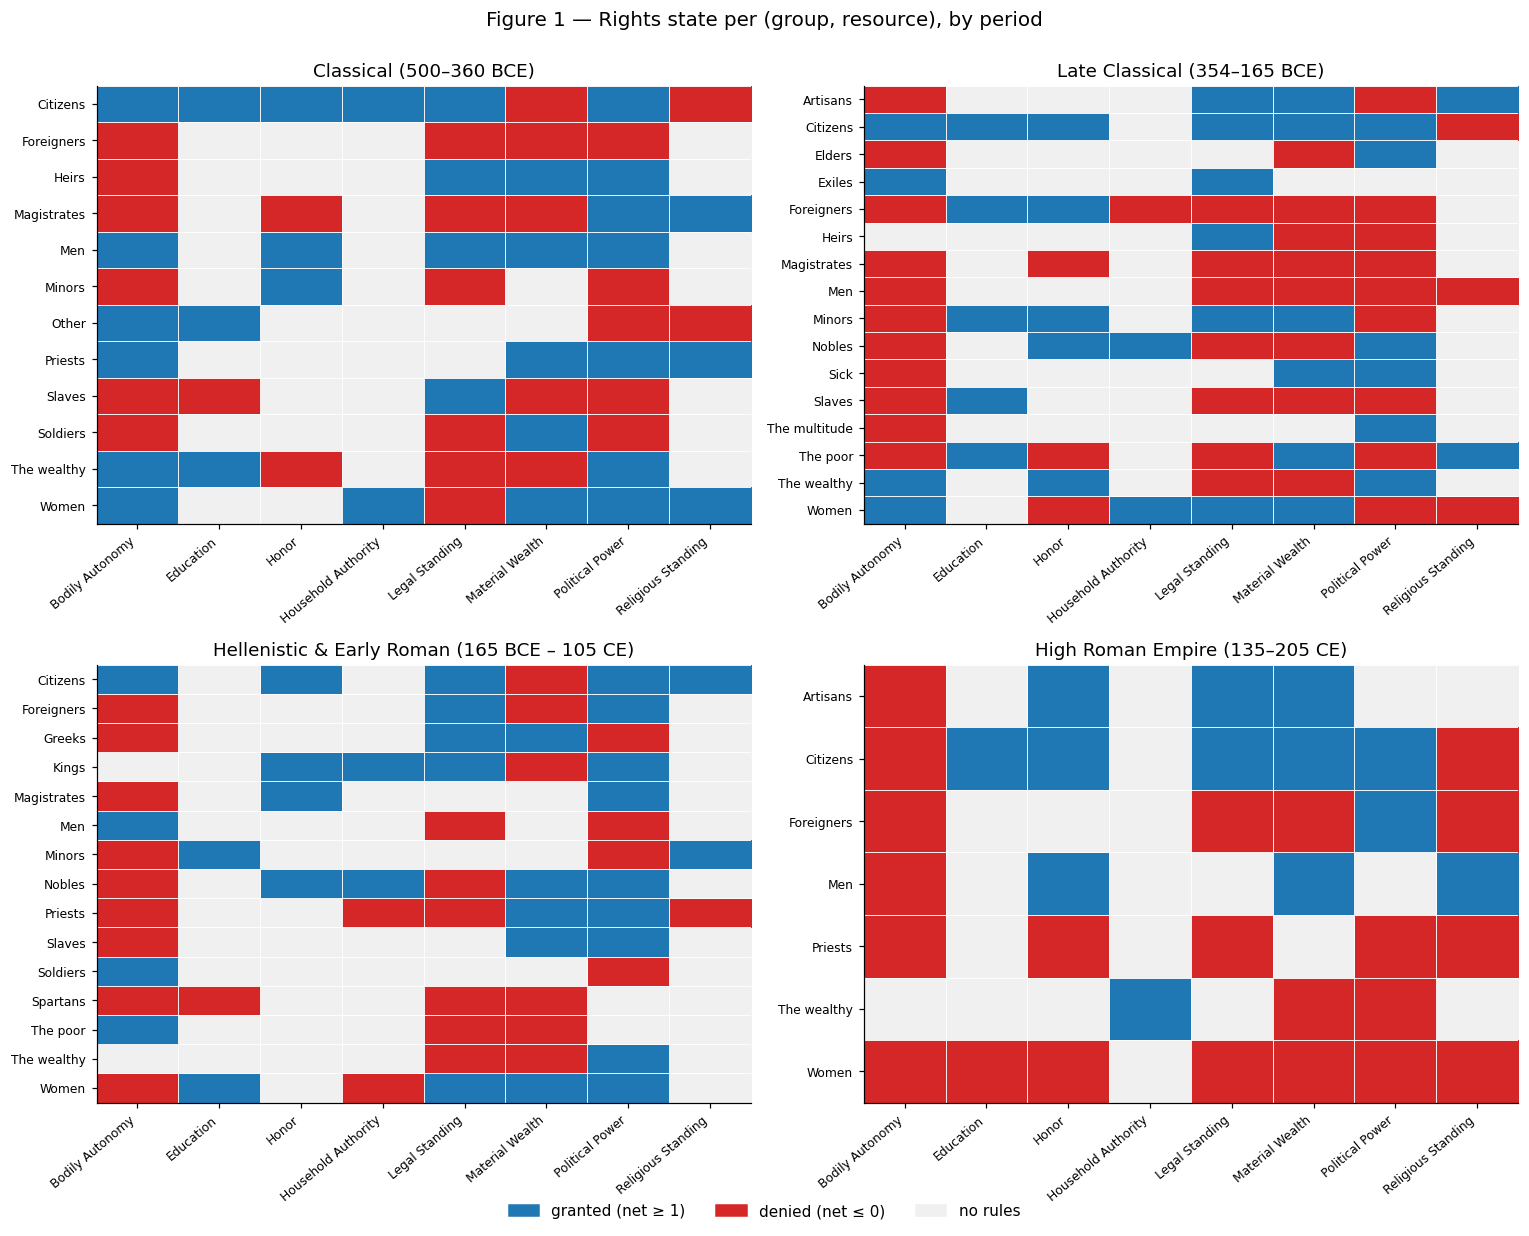

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
cmap = plt.matplotlib.colors.ListedColormap([PALETTE["denied"], PALETTE["granted"]])
cmap.set_bad(PALETTE["no_evidence"])
all_resources = sorted(counts["resource"].unique())

for ax, period in zip(axes.flat, PERIOD_ORDER):
    sub = counts[counts["period"] == period]
    if sub.empty:
        ax.set_title(period + "  (no data)")
        ax.axis("off")
        continue

    # NaN where there is no evidence — distinguishes "no rules" from "denied".
    pivot = (
        sub.pivot(index="group", columns="resource", values="state")
           .reindex(columns=all_resources)
           .sort_index()
    )
    M = np.ma.masked_invalid(pivot.values.astype(float))

    ax.imshow(M, cmap=cmap, vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=40, ha="right", fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_title(period)

    # White grid lines
    ax.set_xticks(np.arange(-.5, len(pivot.columns), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(pivot.index), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.6)
    ax.tick_params(which="minor", length=0)

handles = [
    mpatches.Patch(color=PALETTE["granted"],     label="granted (net ≥ 1)"),
    mpatches.Patch(color=PALETTE["denied"],      label="denied (net ≤ 0)"),
    mpatches.Patch(color=PALETTE["no_evidence"], label="no rules"),
]
fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Figure 1 — Rights state per (group, resource), by period", fontsize=13, y=1.0)
fig.tight_layout()
plt.show()


## 6. Partial order — Hasse diagrams per period

Group $A$ dominates $B$ iff $S_B \subseteq S_A$ (strict). Take the transitive reduction of the strict-dominance DAG.

In [11]:
def build_hasse(rights: dict[str, frozenset]) -> nx.DiGraph:
    """Return the Hasse diagram of strict subset dominance over groups."""
    g = nx.DiGraph()
    for name, s in rights.items():
        g.add_node(name, rights=s, n=len(s))

    for a, b in product(rights, rights):
        if a == b:
            continue
        if rights[b] < rights[a]:  # strict subset
            g.add_edge(a, b)       # arrow from dominator to dominated

    if g.number_of_edges() == 0:
        return g

    h = nx.transitive_reduction(g)
    # transitive_reduction drops node attributes — restore them
    for n in h.nodes:
        h.nodes[n]["rights"] = g.nodes[n]["rights"]
        h.nodes[n]["n"]      = g.nodes[n]["n"]
    return h


def hierarchy_layout(g: nx.DiGraph) -> dict:
    """Position nodes by rights-count (y) and lexicographic order (x)."""
    if g.number_of_nodes() == 0:
        return {}
    by_n: dict[int, list[str]] = {}
    for n, d in g.nodes(data=True):
        by_n.setdefault(d["n"], []).append(n)
    pos = {}
    for n_rights, names in by_n.items():
        names = sorted(names)
        for i, name in enumerate(names):
            x = (i - (len(names) - 1) / 2) * 2.5
            pos[name] = (x, n_rights)
    return pos


hasse_by_period = {p: build_hasse(rights_sets[p]) for p in PERIOD_ORDER}
for p, g in hasse_by_period.items():
    print(f"{p}: {g.number_of_nodes()} groups, {g.number_of_edges()} cover-relations")


Classical (500–360 BCE): 11 groups, 11 cover-relations
Late Classical (354–165 BCE): 14 groups, 17 cover-relations
Hellenistic & Early Roman (165 BCE – 105 CE): 14 groups, 18 cover-relations
High Roman Empire (135–205 CE): 5 groups, 2 cover-relations


### Figure 2: Hasse diagrams of the rights partial order, by period

Vertical position = number of rights granted to the group.
An arrow $A \to B$ means $S_B \subset S_A$ and there is no group strictly between them.
Disconnected groups are incomparable to all others — exactly the *unranked* cases
the partial-order formalism is meant to surface.

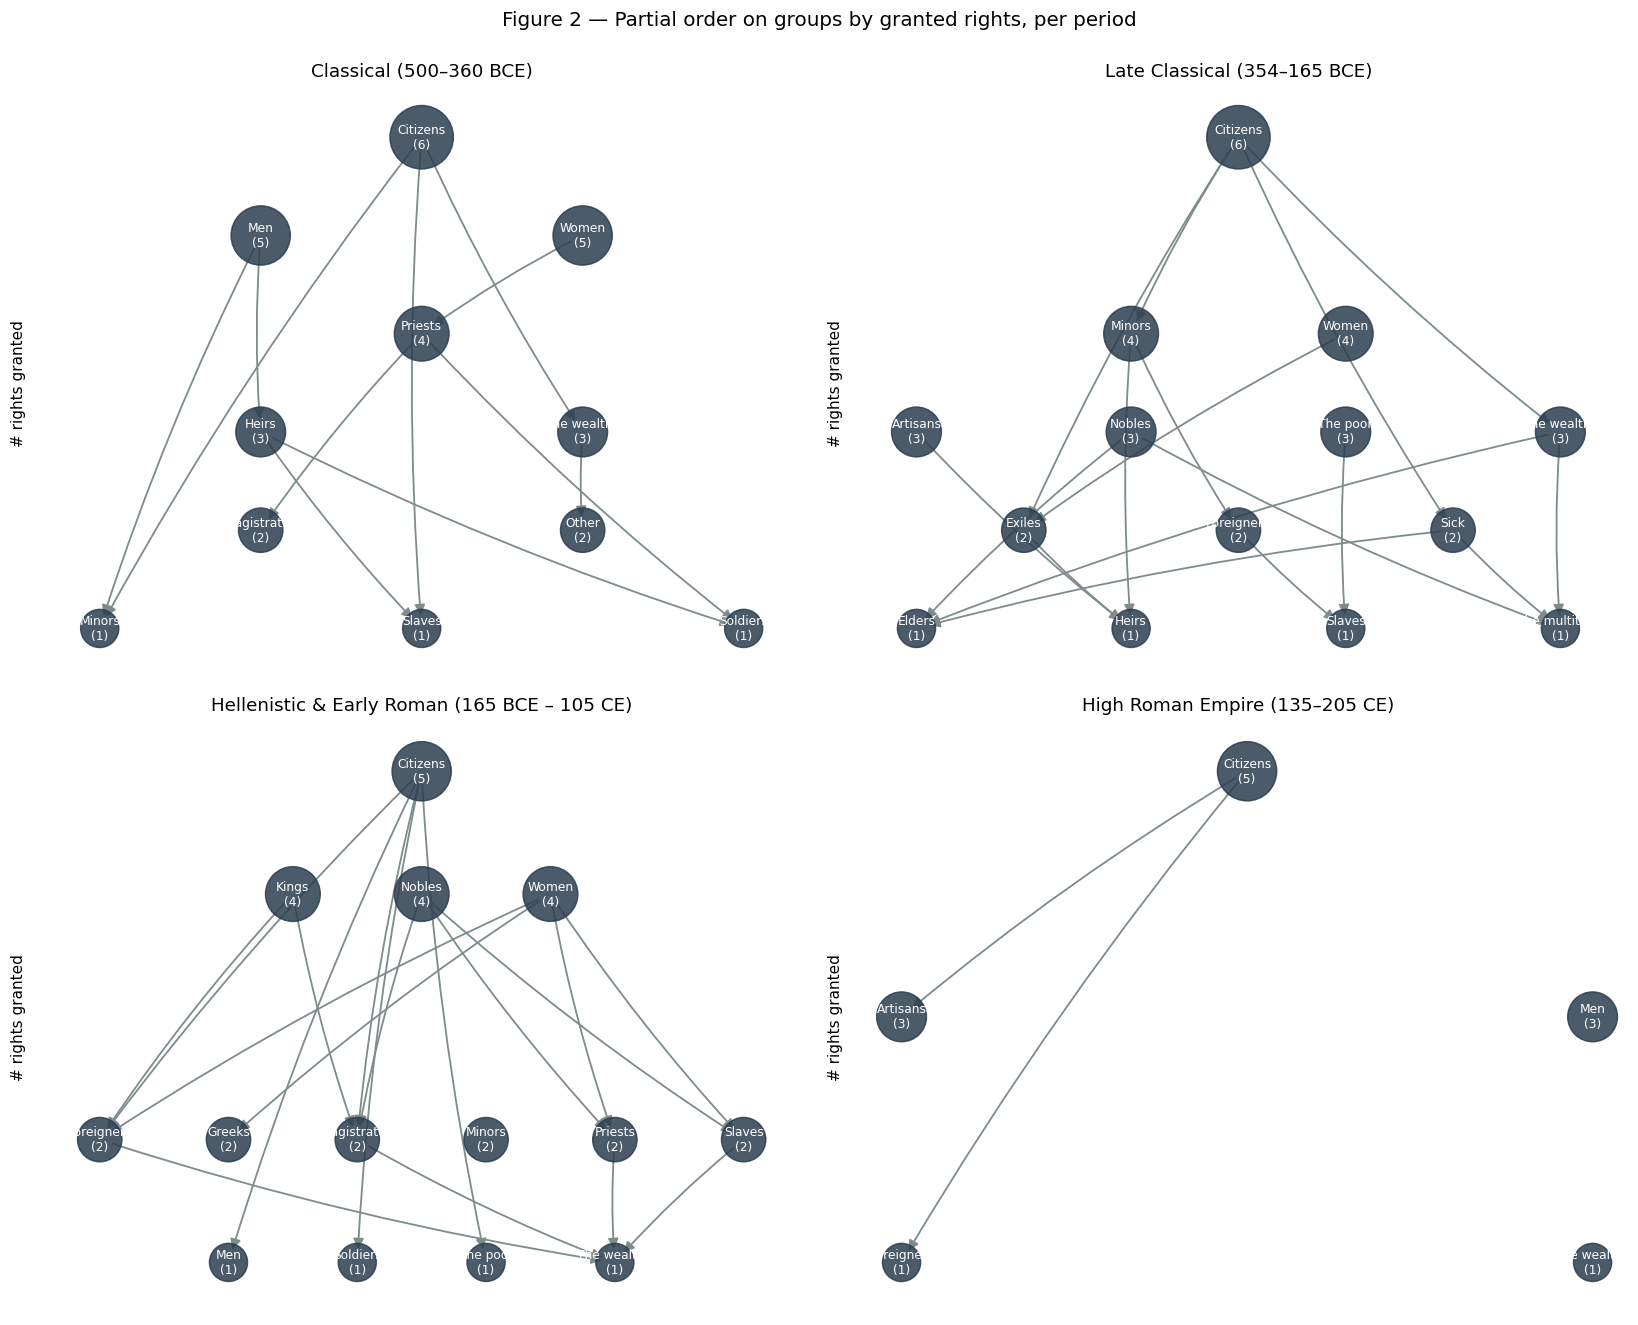

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for ax, period in zip(axes.flat, PERIOD_ORDER):
    g = hasse_by_period[period]
    ax.set_title(period)
    if g.number_of_nodes() == 0:
        ax.text(0.5, 0.5, "no groups pass threshold", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        continue
    pos = hierarchy_layout(g)
    sizes = [400 + 220 * g.nodes[n]["n"] for n in g.nodes]
    nx.draw_networkx_edges(g, pos, ax=ax, edge_color=PALETTE["edge"], arrows=True,
                            arrowsize=14, width=1.2, connectionstyle="arc3,rad=0.04")
    nx.draw_networkx_nodes(g, pos, ax=ax, node_color=PALETTE["node"], node_size=sizes, alpha=0.85)
    labels = {n: f"{n}\n({g.nodes[n]['n']})" for n in g.nodes}
    nx.draw_networkx_labels(g, pos, labels=labels, ax=ax, font_size=8, font_color="white")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_ylabel("# rights granted")
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.suptitle("Figure 2 — Partial order on groups by granted rights, per period", fontsize=13, y=1.0)
fig.tight_layout()
plt.show()

### Comparability diagnostic

How many group pairs in each period are **comparable** under $\subseteq$, vs.
incomparable? A high incomparability share is the signature the formalization is
designed to make visible: rights expansion is multi-dimensional.

In [13]:
rows = []
for period in PERIOD_ORDER:
    rights = rights_sets[period]
    names = list(rights)
    n = len(names)
    if n < 2:
        rows.append({"period": period, "n_pairs": 0, "comparable": 0, "incomparable": 0})
        continue
    comparable = 0
    for i in range(n):
        for j in range(i + 1, n):
            a, b = rights[names[i]], rights[names[j]]
            if a <= b or b <= a:
                comparable += 1
    total = n * (n - 1) // 2
    rows.append({
        "period": period,
        "n_pairs": total,
        "comparable": comparable,
        "incomparable": total - comparable,
        "share_incomparable": (total - comparable) / total if total else 0.0,
    })

comparability = pd.DataFrame(rows)
comparability

,period,n_pairs,comparable,incomparable,share_incomparable
0,Classical (500–360 BCE),55,16,39,0.709091
1,Late Classical (354–165 BCE),91,25,66,0.725275
2,Hellenistic & Early Roman (165 BCE – 105 CE),91,26,65,0.714286
3,High Roman Empire (135–205 CE),10,2,8,0.800000


## 7. Period comparison — is there an expansion of rights?

Three views:

- **Figure 3** — total granted / denied cells per period (absolute and normalised).
- **Figure 4** — per resource type, the number of distinct groups that obtain the right in each period.
- **Figure 5** — average number of rights per group, with a 95% bootstrap confidence band.

The periods are not comparably sampled (n = 283 / 397 / 155 / 85 rules) — always read the normalised view.

In [14]:
# Per-period state counts — the data behind Figure 3
state_labels = {1: "granted", -1: "denied"}
period_state = (
    counts.assign(state_label=counts["state"].map(state_labels))
          .groupby(["period", "state_label"]).size()
          .unstack("state_label", fill_value=0)
          .reindex(index=PERIOD_ORDER, columns=["granted", "denied"], fill_value=0)
)
period_state["total_cells"] = period_state.sum(axis=1)
period_state["share_granted"] = period_state["granted"] / period_state["total_cells"]
period_state["share_denied"]  = period_state["denied"]  / period_state["total_cells"]

period_state

state_label,granted,denied,total_cells,share_granted,share_denied
period,,,,,
Classical (500–360 BCE),33,27,60,0.550000,0.450000
Late Classical (354–165 BCE),36,42,78,0.461538,0.538462
Hellenistic & Early Roman (165 BCE – 105 CE),33,29,62,0.532258,0.467742
High Roman Empire (135–205 CE),13,22,35,0.371429,0.628571


### Figure 3: Granted vs. denied rights cells, by period

Left: absolute counts of `(group, resource)` cells in each state.
Right: the same data normalised to shares within each period.

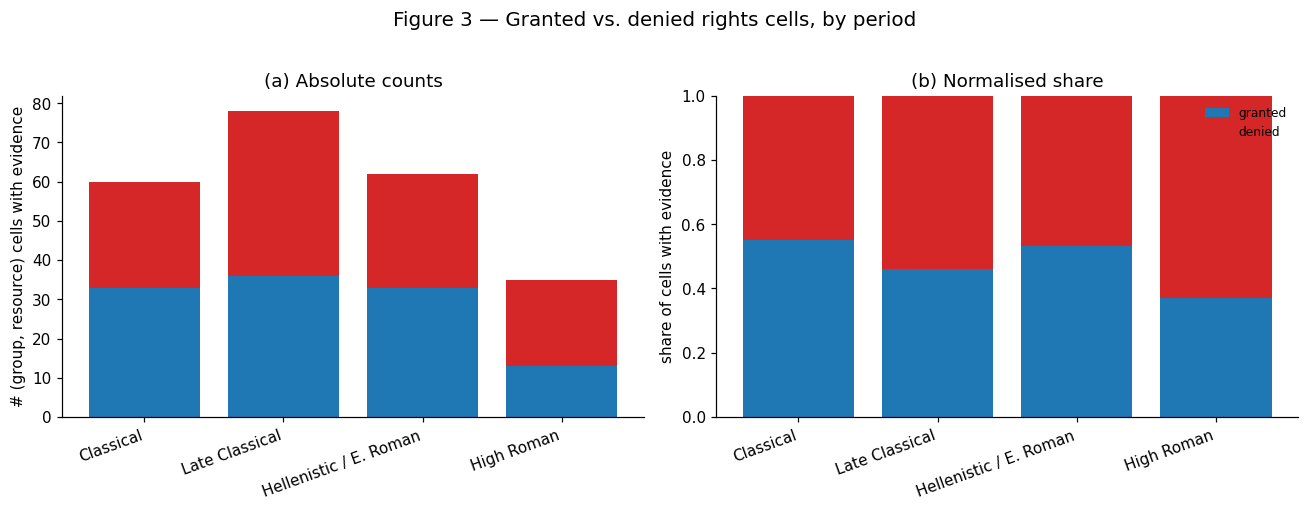

In [15]:
fig, (ax_abs, ax_share) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

x = np.arange(len(PERIOD_ORDER))
labels = [PERIOD_SHORT[p] for p in PERIOD_ORDER]
g = period_state["granted"].values
d = period_state["denied"].values

# (a) absolute counts — stacked bar
ax_abs.bar(x, g, color=PALETTE["granted"], label="granted")
ax_abs.bar(x, d, bottom=g, color=PALETTE["denied"], label="denied")
ax_abs.set_xticks(x); ax_abs.set_xticklabels(labels, rotation=20, ha="right")
ax_abs.set_ylabel("# (group, resource) cells with evidence")
ax_abs.set_title("(a) Absolute counts")

# (b) normalised shares — same stacked bar, scaled to 1
total = period_state["total_cells"].values
ax_share.bar(x, g / total, color=PALETTE["granted"], label="granted")
ax_share.bar(x, d / total, bottom=g / total, color=PALETTE["denied"], label="denied")
ax_share.set_xticks(x); ax_share.set_xticklabels(labels, rotation=20, ha="right")
ax_share.set_ylabel("share of cells with evidence")
ax_share.set_ylim(0, 1)
ax_share.set_title("(b) Normalised share")
ax_share.legend(loc="upper right", frameon=False, fontsize=8)

fig.suptitle("Figure 3 — Granted vs. denied rights cells, by period", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

### Figure 4: Number of groups granted each right, by period

Per resource type, count the distinct groups whose rights set contains that
resource in each period. An expanding right shows a rising bar across the four
periods; a contracting right falls.

In [16]:
# For each (period, resource), count distinct groups with the right granted.
granted = counts[counts["state"] == 1]
groups_per_right = (
    granted.groupby(["period", "resource"])["group"].nunique()
           .unstack("resource", fill_value=0)
           .reindex(index=PERIOD_ORDER, fill_value=0)
)
# Sort resources by total expansion across periods, descending
groups_per_right = groups_per_right[groups_per_right.sum().sort_values(ascending=False).index]

groups_per_right

resource,Political Power,Material Wealth,Legal Standing,Honor,Bodily Autonomy,Education,Religious Standing,Household Authority
period,,,,,,,,
Classical (500–360 BCE),7,5,4,3,6,3,3,2
Late Classical (354–165 BCE),6,6,6,5,4,5,2,2
Hellenistic & Early Roman (165 BCE – 105 CE),9,5,5,4,4,2,2,2
High Roman Empire (135–205 CE),2,3,2,3,0,1,1,1


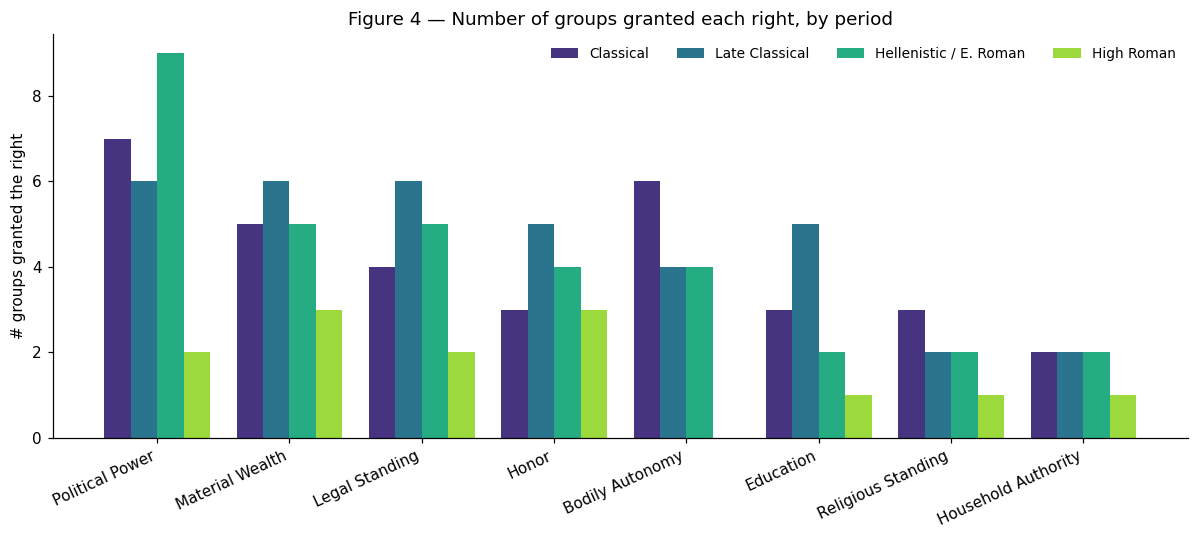

In [17]:
fig, ax = plt.subplots(figsize=(11, 5))

resources = list(groups_per_right.columns)
n_periods = len(PERIOD_ORDER)
bar_w = 0.8 / n_periods
x = np.arange(len(resources))

period_colors = plt.cm.viridis(np.linspace(0.15, 0.85, n_periods))

for k, period in enumerate(PERIOD_ORDER):
    vals = groups_per_right.loc[period].values
    ax.bar(x + (k - (n_periods - 1) / 2) * bar_w, vals,
           width=bar_w, color=period_colors[k], label=PERIOD_SHORT[period])

ax.set_xticks(x)
ax.set_xticklabels(resources, rotation=25, ha="right")
ax.set_ylabel("# groups granted the right")
ax.set_title("Figure 4 — Number of groups granted each right, by period")
ax.legend(frameon=False, fontsize=9, ncol=4, loc="upper right")
fig.tight_layout()
plt.show()

### Figure 5: Average number of rights per group, by period

Bootstrap 95% confidence band (1,000 resamples over groups within each period).
This is the most direct one-number test of the *expansion* hypothesis: if the
mean drifts upward across periods, the typical group is gaining rights.

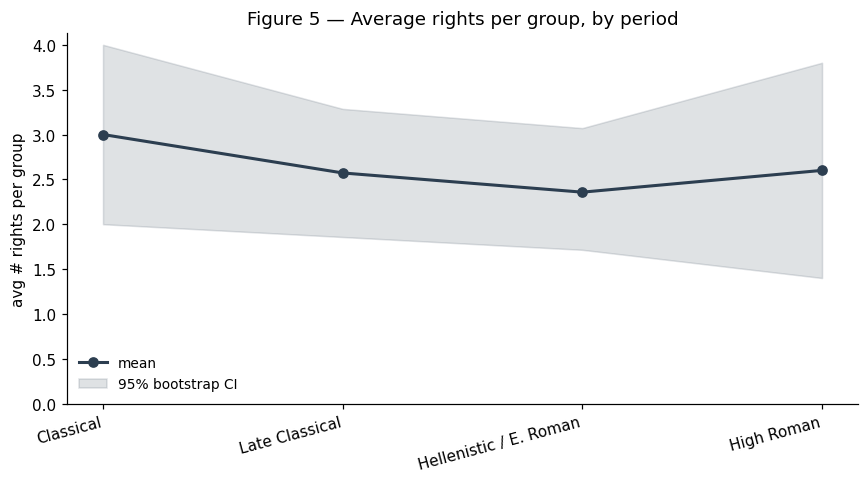

,period,mean_rights_per_group,ci_low,ci_high
0,Classical,3.000000,2.000000,4.000000
1,Late Classical,2.571429,1.857143,3.285714
2,Hellenistic / E. Roman,2.357143,1.714286,3.071429
3,High Roman,2.600000,1.400000,3.800000


In [18]:
N_BOOT = 1000
rng = np.random.default_rng(SEED)

means, lo, hi = [], [], []
for period in PERIOD_ORDER:
    sizes = np.array([len(s) for s in rights_sets[period].values()])
    if len(sizes) == 0:
        means.append(0.0); lo.append(0.0); hi.append(0.0)
        continue
    boots = rng.choice(sizes, size=(N_BOOT, len(sizes)), replace=True).mean(axis=1)
    means.append(sizes.mean())
    lo.append(np.quantile(boots, 0.025))
    hi.append(np.quantile(boots, 0.975))

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(PERIOD_ORDER))
ax.plot(x, means, marker="o", color=PALETTE["node"], linewidth=2, label="mean")
ax.fill_between(x, lo, hi, color=PALETTE["node"], alpha=0.15, label="95% bootstrap CI")
ax.set_xticks(x); ax.set_xticklabels([PERIOD_SHORT[p] for p in PERIOD_ORDER], rotation=15, ha="right")
ax.set_ylabel("avg # rights per group")
ax.set_ylim(bottom=0)
ax.set_title("Figure 5 — Average rights per group, by period")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

pd.DataFrame({
    "period": [PERIOD_SHORT[p] for p in PERIOD_ORDER],
    "mean_rights_per_group": means,
    "ci_low": lo,
    "ci_high": hi,
})

## 8. Summary

- Threshold rule is binary: `net ≥ 1` is granted, `net ≤ 0` is denied.
- Dominant groups (Citizens, Nobles, Magistrates, Romans) sit near the top of every period; Slaves, Foreigners, Women and the Poor cluster at the bottom.
- High incomparability share (~70–80%) — one-dimensional rights indices would have to break ties artificially.
- Read **Fig 3(b)** (normalised share) and **Fig 5** (mean ± CI) to evaluate expansion; **Fig 4** shows *which* rights drive the change.

Knobs to revisit: `GRANT_THRESHOLD`, `MIN_RULES_PER_GROUP`, and the atomisation of `group_meta` / `resource_type`.